# Assignment: week 1

In [267]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

## Datan esikäsittely

Haetaan iris datasetti ja one-hot enkoodataan se ```pd.get_dummies()``` metodilla.

One-hot tekee kohdemuuttujasta binäärisen, arvoilla True/False.

In [269]:
df = pd.read_csv("../datasets/iris.data.txt", header=None)
df = pd.get_dummies(df)
df

,0,1,2,3,4_Iris-setosa,4_Iris-versicolor,4_Iris-virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


Sekoitetaan datasetin indeksit.

Uudelleenjärjestetään datasetti käyttäen edellämainittuja indeksejä.

In [270]:
idx = df.index.to_list()
np.random.shuffle(idx)

df = df.loc[idx].reset_index(drop=True)
df

,0,1,2,3,4_Iris-setosa,4_Iris-versicolor,4_Iris-virginica
0,6.2,2.9,4.3,1.3,False,True,False
1,6.3,2.5,5.0,1.9,False,False,True
2,5.5,4.2,1.4,0.2,True,False,False
3,5.9,3.0,4.2,1.5,False,True,False
4,5.3,3.7,1.5,0.2,True,False,False
...,...,...,...,...,...,...,...
145,5.9,3.0,5.1,1.8,False,False,True
146,4.9,3.1,1.5,0.1,True,False,False
147,6.9,3.2,5.7,2.3,False,False,True
148,6.5,3.0,5.8,2.2,False,False,True


Erotetaan selittävät muuttujat kohdemuuttujasta.

- ```X``` = selittävät muuttujat
- ```y``` = kohdemuuttuja

In [271]:
X = df.iloc[:, :4].values
y = df.iloc[:, 4:].values

In [283]:
for i in range(10):
    print(X[i])

[6.2 2.9 4.3 1.3]
[6.3 2.5 5.  1.9]
[5.5 4.2 1.4 0.2]
[5.9 3.  4.2 1.5]
[5.3 3.7 1.5 0.2]
[5.4 3.  4.5 1.5]
[4.6 3.2 1.4 0.2]
[5.5 3.5 1.3 0.2]
[6.7 2.5 5.8 1.8]
[5.4 3.9 1.3 0.4]


In [282]:
for i in range(10):
    print(y[i])

[False  True False]
[False False  True]
[ True False False]
[False  True False]
[ True False False]
[False  True False]
[ True False False]
[ True False False]
[False False  True]
[ True False False]


## Mallinnus

Tuotetaan `Sequential` malli, joka ottaa `Input` syötekerroksen muotonaan 4-ulotteisen vektorin.

Vektori koostuu iris datasetin neljästä selittävästä muuttujasta:
- sepal length
- sepal width
- petal length
- petal width

Malli hyödyntää yhtä `Dense` piilokerrosta. Piilokerros on toteutettu 16 yksiköllä.

Ulostulo (Output) kerros sisältää 3 yksikköä, jotka vastaavat datasetin kohdemuuttujia.

Aktivaatiofunktioina toimii `ReLU` piilokerroksella ja `softmax` ulostulokerroksella.

In [274]:
model = Sequential([
    Input(shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

Kootaan malli käyttäen `Adam` optimoijaa ja metriikkana tarkkuutta (accuracy). 

Adamin `learning_rate` parametrina päädyin `0.008`, joka tuotti vaaditun tarkkuuden mallille.

In [275]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.008),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Malli sovitetaan iris datasetillä käyttäen parametreja:
- `epochs` = 30 tuotti yleensä parhaat tulokset. Kun kokeilin pienempiä arvoja, malli tuntui jähmettyvän noin 80–90 %:n tarkkuuteen.
- `batch_size` = 32, joka on myös oletusarvo, näytti toimivan ihan hyvin. Kokeilin useita arvoja, mutta päädyin lopulta oletusarvoon, koska muut arvot eivät tuottaneet huomattavia positiivisia eroja.
- `validation_split` = 0.2 eli data on jaettu 80/20.  

In [276]:
history = model.fit(X, y, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4167 - loss: 2.2882 - val_accuracy: 0.2000 - val_loss: 2.8517
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3667 - loss: 1.6072 - val_accuracy: 0.2000 - val_loss: 1.7030
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2917 - loss: 1.1596 - val_accuracy: 0.4667 - val_loss: 1.0777
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2750 - loss: 1.1077 - val_accuracy: 0.5667 - val_loss: 0.8880
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5083 - loss: 0.9930 - val_accuracy: 0.8000 - val_loss: 0.8088
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6167 - loss: 0.8253 - val_accuracy: 0.4333 - val_loss: 0.9203
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7083 - loss: 0.7472 - val_accuracy: 0.4667 - val_loss: 0.9139
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7167 - loss: 0.7072 - val_accuracy: 0.4667 - val_loss: 0.8701

Plotataan mallin kehitys jokaisella epochilla.

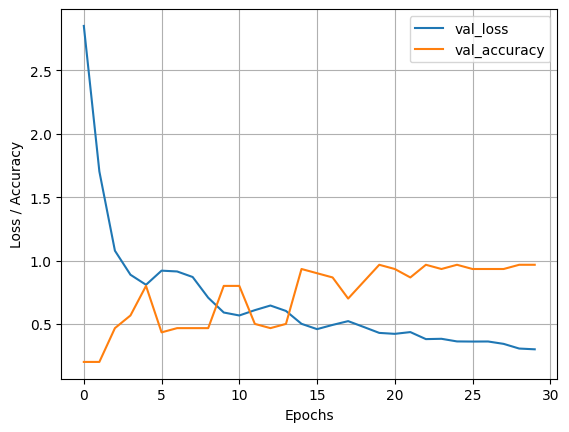

In [277]:
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Nähdään, että `val_loss` laskee räjähdysmäisesti noin 5 epochin ajan, minkä jälkeen lasku hidastuu ja jatkuu lähes lineaarisesti loppuajan.

`val_accuracy` nousee aluksi vähän epäröivästi, mutta tasaantuu lopussa vaadittuihin arvoihin noin 20 epochin jälkeen.

In [278]:
test_loss, test_acc = model.evaluate(X, y)
print("Models performance")
print(f"Accuracy: {test_acc:.4f}\nLoss: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9800 - loss: 0.2902
Models performance
Accuracy: 0.9800
Loss: 0.2902


Lopuksi katsotaan `model.summary()`:lla mallin parametrien määrä ja kerroksien muodot.

In [279]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395 (1.55 KB)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 264 (1.04 KB)